c:\Users\glotzie\Documents\EV_Range_Predection_DL\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 163872.2344 - mae: 391.9133 - val_loss: 170404.1250 - val_mae: 397.1080
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 163478.3594 - mae: 391.3849 - val_loss: 169898.7500 - val_mae: 396.4511
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 162967.9219 - mae: 390.7065 - val_loss: 169216.5312 - val_mae: 395.5629
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 162266.9219 - mae: 389.7726 - val_loss: 168285.5625 - val_mae: 394.3533
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 161314.0156 - mae: 388.5056 - val_loss: 167031.4688 - val_mae: 392.7261
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 160058.6719 - mae: 386.8080 - val_loss: 165376.8906 - val_mae: 390.5892
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 158411.2812 - mae: 384.6113 - val_loss: 163257.0000 - val_mae: 387.8412
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 156341.8594 - mae

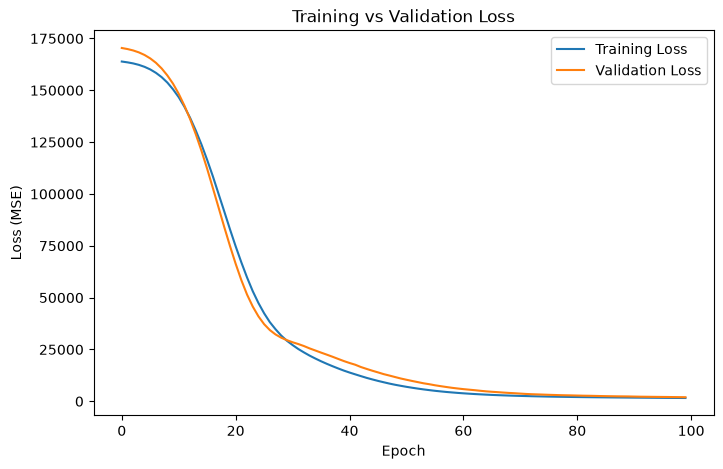

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the dataset
X_train_scaled = pd.read_csv("../Data/Processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../Data/Processed/X_test_scaled.csv")

y_train = pd.read_csv("../Data/Processed/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/Processed/y_test.csv").squeeze()

# Build the neural network model
model = Sequential([
    Dense(64, activation="relu", input_shape=(5,)),
    Dense(32, activation="relu"),
    Dense(1)
])

# Compile the model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)

# Print the test loss and mean absolute error
print(f"Test Loss: {test_loss}")    
print(f"Test MAE: {test_mae}")    


# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE (km)")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

# Save the trained model
model.save("../Models/ann_model.keras")


